In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

# **SCHEMA**

### **LLM Pydantic Schema**

In [2]:
from pydantic import BaseModel, Field
from typing import Literal
class llm_schema(BaseModel):
    category: Literal['insta','twitter','linkedin'] = Field(description='the platform for which the user wishes to generate the post')
    topic: str = Field(description="topic of the post to generate")

In [3]:
model_with_schema = model.with_structured_output(llm_schema)

In [4]:
model_with_schema.invoke("I want to generate a psot for linkedin about ai")

llm_schema(category='linkedin', topic='ai')

### **State Schema**

In [5]:
class graph_schema(BaseModel):
    input: str
    topic :str
    category: str
    linkedin_post: str
    x_post: str
    insta_post: str

In [6]:
def decider_node(state:graph_schema)-> graph_schema:
    input = state.input
    category = model_with_schema.invoke(input).category
    topic = model_with_schema.invoke(input).topic
    state.category = category
    state.topic = topic
    return state

In [7]:
def create_post_linkedin(state:graph_schema) -> graph_schema:

    topic = state.topic

    post = model.invoke(f"write a linkedin post on {topic}").content

    state.linkedin_post = post

    return {"linkedin_post": post}

In [8]:
def create_post_x(state:graph_schema) -> graph_schema:

    topic = state.topic
    post = model.invoke(f"write a X/Twitter post on {topic}").content

    state.x_post = post

    return {"x_post":post}

In [9]:
def create_post_insta(state:graph_schema) -> graph_schema:

    topic = state.topic

    post = model.invoke(f"write a Instagram post on {topic}").content

    state.insta_post = post

    return {"insta_post":post}

In [10]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)


graph.add_node("decider",decider_node)
graph.add_node("create_post_insta", create_post_insta)
graph.add_node("create_post_linkedin",create_post_linkedin)
graph.add_node("create_post_x",create_post_x)


In [11]:
def condition(state:graph_schema) -> str:
    category = state.category

    if category == 'insta':
        return 'create_post_insta'
    if category == 'x':
        return 'create_post_x'
    if category == 'linkedin':
        return 'create_post_linkedin'
    else:
        raise ValueError("Invalid Category")

In [12]:
graph.add_edge(START,"decider")
graph.add_conditional_edges("decider",condition,{
    "create_post_insta":"create_post_insta",
    "create_post_linkedin":"create_post_linkedin",
    "create_post_x":"create_post_x"
    })
graph.add_edge("create_post_insta",END)
graph.add_edge("create_post_x",END)
graph.add_edge("create_post_linkedin",END)

In [13]:
RouteGraph = graph.compile()

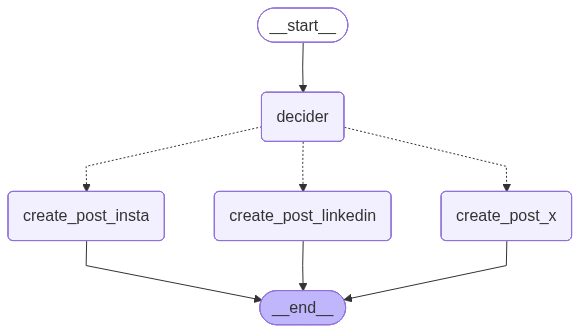

In [14]:
from IPython.display import Image, display

Image(RouteGraph.get_graph().draw_mermaid_png())

In [15]:
RouteGraph.invoke({
    "input":"create a post for linkedin on advantages of ai",
    "topic":"",
    "category":"",
    "linkedin_post":"",
    "x_post":"",
    "insta_post":""
})

{'input': 'create a post for linkedin on advantages of ai',
 'topic': 'advantages of AI',
 'category': 'linkedin',
 'linkedin_post': "Here are a few options for a LinkedIn post about the advantages of AI, ranging in tone and focus. Choose the one that best fits your style and audience!\n\n---\n\n**Option 1: Concise & Impactful**\n\n## Unlocking Potential: The Transformative Power of AI 🚀\n\nArtificial Intelligence is no longer a futuristic concept; it's a present-day reality revolutionizing how we work and live.\n\nHere are just a few of the game-changing advantages AI brings:\n\n✅ **Enhanced Efficiency:** Automating repetitive tasks, freeing up human talent for more strategic initiatives.\n✅ **Improved Decision-Making:** Analyzing vast datasets to uncover insights and drive data-backed strategies.\n✅ **Personalized Experiences:** Tailoring products, services, and customer interactions like never before.\n✅ **Innovation Acceleration:** Fueling breakthroughs in research, development, an